### ==============================================================================
## Processing of Moving Vessel Profiler Data - code 1_QC
### Authors: Elisabet Verger-Miralles (everger@imedea.uib-csic.es)
### Data from BioSWOT experiment
# 
**DESCRIPTION**:
This script performs Step 1 Quality Control (QC) specifically on the profiles
selected during Step 0.2. It reads the 'selected_profiles.csv' catalog, 
locates the corresponding raw NetCDF files, and applies depth truncation, 
outlier detection (despiking via Hampel filter), and linear gap-filling.
Finally, it calculates the descent rate (w) and exports high-resolution, 
quality-controlled NetCDF files.
#
INPUT: 'selected_profiles.csv' and raw *_downcast.nc files.
#
OUTPUT: QC'd NetCDF files (*_step1_qc.nc) in 'processed_step1_highres_qc'.
### ==============================================================================

In [1]:

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import gsw

# =========================
# PATHS
# =========================
ROOT_BIO = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\Data")

LEG_CFG = {
    "bioswot": {
        "raw_dir": ROOT_BIO / "raw",  
        
        "selected_csv": ROOT_BIO / "selected_profiles" / "selected_profiles.csv",
        
        "pmax": 400.0,  
        "pmin": 10.0    
    }
}

OUT_SUBDIR = "processed_step1_highres_qc"

# =========================
# QC PARAMETERS
# =========================
T_RANGE = (-2.0, 35.0)
SP_RANGE = (30.0, 42.0)   

# Despike settings
DESPIKE_ON = True
DC_K = 15; DC_NSIG = 4.0; DC_PAD = 1
SP_K = 21; SP_NSIG = 3.5; SP_PAD = 1
FILL_MAX_GAP_DC = 7
FILL_MAX_GAP_SP = 9
FS_HZ = 25 

# =========================
# FUNCTIONS
# =========================

def keep_only_depth(p, pmin, pmax):
    """Creates a boolean mask to keep data within specified depth limits."""
    p = np.asarray(p, dtype=float)
    return np.isfinite(p) & (p >= pmin) & (p <= pmax)

def compute_w_from_scan_index(p, fs_hz=25.0):
    """Calculates descent rate (w) based on pressure gradient and sampling frequency."""
    p = np.asarray(p, float)
    dp_dscan = np.gradient(p) 
    w = fs_hz * dp_dscan       
    return w

def hampel_flags(x, k=11, n_sig=4.0):
    """
    Applies a Hampel filter to detect outliers based on Median Absolute Deviation (MAD).
    Returns a boolean array where True indicates an outlier.
    """
    x = np.asarray(x, float)
    n = len(x)
    out = np.zeros(n, dtype=bool)
    if k < 3: return out
    if k % 2 == 0: k += 1
    half = k // 2
    for i in range(n):
        i0 = max(0, i - half)
        i1 = min(n, i + half + 1)
        w = x[i0:i1]
        w = w[np.isfinite(w)]
        if w.size < max(7, k // 2): continue
        med = np.nanmedian(w)
        mad = np.nanmedian(np.abs(w - med))
        if not np.isfinite(mad) or mad == 0: continue
        sigma = 1.4826 * mad
        if np.isfinite(x[i]) and np.abs(x[i] - med) > n_sig * sigma:
            out[i] = True
    return out

def expand_flags(flag, pad=1):
    """Expands the outlier flag to neighboring points defined by 'pad'."""
    flag = np.asarray(flag, bool)
    n = len(flag)
    out = flag.copy()
    idx = np.where(flag)[0]
    for j in idx:
        for pp in range(-pad, pad + 1):
            k = j + pp
            if 0 <= k < n: out[k] = True
    return out

def despike_by_dC(C, k=15, n_sig=4.0, pad=1):
    """Detects spikes based on the derivative of Conductivity (dC)."""
    C = np.asarray(C, float)
    dC = np.diff(C, prepend=C[0])
    flag_dC = hampel_flags(dC, k=k, n_sig=n_sig)
    return expand_flags(flag_dC, pad=pad)

def despike_by_SP(SP, k=21, n_sig=3.5, pad=1):
    """Detects spikes directly on Salinity (SP)."""
    return expand_flags(hampel_flags(SP, k=k, n_sig=n_sig), pad=pad)

def fill_spikes_linear(x, flag, x_axis=None, max_gap=7):
    """Fills detected spikes using linear interpolation over the valid data."""
    x = np.asarray(x, float).copy()
    flag = np.asarray(flag, bool)
    if x_axis is None: x_axis = np.arange(len(x), dtype=float)
    else: x_axis = np.asarray(x_axis, float)
    good = np.isfinite(x) & (~flag) & np.isfinite(x_axis)
    if good.sum() < 5: return x 
    idx = np.where(flag)[0]
    if idx.size == 0: return x
    x_interp = np.interp(x_axis, x_axis[good], x[good])
    x[idx] = x_interp[idx]
    return x

# =========================
# MAIN PROCESSING LOOP
# =========================

for leg, cfg in LEG_CFG.items():
    raw_dir = cfg["raw_dir"]
    selected_csv = cfg["selected_csv"]
    pmax = float(cfg["pmax"])
    pmin = float(cfg["pmin"])

    out_dir = raw_dir.parent / OUT_SUBDIR
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n[{leg.upper()}] Processing BioSWOT...")
    print(f"   Input Raw: {raw_dir}")
    print(f"   Selection: {selected_csv}")
    print(f"   Limits:    {pmin} - {pmax} dbar")
    
    if not selected_csv.exists():
        print(f"⚠️ CSV not found. Skipping {leg}.")
        continue

    # 1. Read the selected profiles CSV
    df_sel = pd.read_csv(selected_csv)
    
    # Ensure the 'file' column exists (created in Step 0.2)
    if 'file' not in df_sel.columns:
        print(f"⚠️ CSV is missing the 'file' column. Found columns: {df_sel.columns}")
        continue
        
    file_list = df_sel['file'].values
    print(f"   Target profiles: {len(file_list)}")

    kept = 0
    # 2. Iterate ONLY through the files listed in the CSV
    for filename in file_list:
        f_path = raw_dir / filename
        
        if not f_path.exists():
            print(f"⚠️ File missing: {filename} (in CSV but not in raw folder)")
            continue

        try:
            ds = xr.open_dataset(f_path)
            
            # --- 1. VARIABLE LOADING ---
            vars_map = {
                "t1": ["t1", "Temp"],
                "c1": ["c1", "Cond"],
                "pressure": ["pressure", "Press", "Depth"]
            }
            
            def get_var(ds, keys):
                for k in keys:
                    if k in ds: return ds[k].values.astype(float)
                return None

            T = get_var(ds, vars_map["t1"])
            C = get_var(ds, vars_map["c1"])
            p = get_var(ds, vars_map["pressure"])

            if T is None or C is None or p is None:
                ds.close(); continue

            # --- 2. DEPTH & RANGE FILTERING ---
            mask_depth = keep_only_depth(p, pmin, pmax)
            mask_phys = (T >= T_RANGE[0]) & (T <= T_RANGE[1])
            valid = mask_depth & mask_phys
            
            T_qc = np.where(valid, T, np.nan)
            C_qc = np.where(valid, C, np.nan)
            
            # --- 3. DESPIKING & GAP FILLING ---
            flag_dc = np.zeros_like(C, dtype=bool)
            flag_sp = np.zeros_like(C, dtype=bool)

            if DESPIKE_ON and np.sum(np.isfinite(C_qc)) > 10:
                flag_dc = despike_by_dC(C_qc, k=DC_K, n_sig=DC_NSIG, pad=DC_PAD)
                if flag_dc.any():
                    C_qc = fill_spikes_linear(C_qc, flag_dc, x_axis=p, max_gap=FILL_MAX_GAP_DC)
                    T_qc = fill_spikes_linear(T_qc, flag_dc, x_axis=p, max_gap=FILL_MAX_GAP_DC)

                SP_tmp = gsw.SP_from_C(C_qc, T_qc, p)
                flag_sp = despike_by_SP(SP_tmp, k=SP_K, n_sig=SP_NSIG, pad=SP_PAD)
                if flag_sp.any():
                    C_qc = fill_spikes_linear(C_qc, flag_sp, x_axis=p, max_gap=FILL_MAX_GAP_SP)
                    T_qc = fill_spikes_linear(T_qc, flag_sp, x_axis=p, max_gap=FILL_MAX_GAP_SP)

            # --- 4. FINAL CALCULATIONS ---
            SP_final = gsw.SP_from_C(C_qc, T_qc, p)
            SP_final = np.where((SP_final >= SP_RANGE[0]) & (SP_final <= SP_RANGE[1]), SP_final, np.nan)
            w = compute_w_from_scan_index(p, fs_hz=FS_HZ)
            
            # --- 5. EXPORT DATASET ---
            ds_out = ds.copy(deep=True)
            ds_out["t1"] = (("scan",), T_qc)
            ds_out["c1"] = (("scan",), C_qc)
            ds_out["s_raw"] = (("scan",), SP_final)
            ds_out["w_descent"] = (("scan",), w)
            ds_out["flag_qc"] = (("scan",), (flag_dc | flag_sp).astype(np.int8))
            
            # Atributos extra
            ds_out.attrs["pmin_used"] = pmin
            ds_out.attrs["pmax_used"] = pmax
            
            clean_stem = f_path.stem.replace('_downcast','')
            out_name = f"{clean_stem}_step1_qc.nc"
            ds_out.to_netcdf(out_dir / out_name)
            
            ds.close()
            kept += 1
            
        except Exception as e:
            print(f"❌ Error en {filename}: {e}")

    print(f"✅ END BIOSWOT. {kept} processed in:\n{out_dir}")

c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED



[BIOSWOT] Processing BioSWOT...
   Input Raw: C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\Data\raw
   Selection: C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\Data\selected_profiles\selected_profiles.csv
   Limits:    10.0 - 400.0 dbar
   Target profiles: 633
✅ END BIOSWOT. 633 processed in:
C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\Data\processed_step1_highres_qc


In [2]:
# import matplotlib.pyplot as plt
# import xarray as xr
# import numpy as np
# from pathlib import Path
# import random
# import gsw

# # ==========================
# # CONFIGURACIÓN
# # ==========================
# BASE_DIR = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_bioswot_nc_final_processing")

# # Carpeta de datos PROCESADOS (Step 1)
# QC_DIR = BASE_DIR / "processed_step1_highres_qc"

# # Carpeta de datos RAW (Step 0.1) para comparar
# RAW_DIR = BASE_DIR / "raw_step0"

# # Dónde guardar las figuras
# FIG_DIR = BASE_DIR / "DIAG_STEP1_RANDOM"
# FIG_DIR.mkdir(exist_ok=True)

# # Cuántos perfiles aleatorios quieres ver
# N_PLOTS = 6

# # ==========================
# # LÓGICA DE PLOTEO
# # ==========================

# # 1. Obtener lista de archivos procesados
# qc_files = sorted(list(QC_DIR.glob("*_step1_qc.nc")))

# if not qc_files:
#     print("❌ No hay archivos procesados en la carpeta QC.")
# else:
#     # 2. Seleccionar N al azar
#     # Si hay menos archivos que N_PLOTS, cogemos todos
#     n_sample = min(len(qc_files), N_PLOTS)
#     selected_files = random.sample(qc_files, n_sample)
    
#     print(f"Generando plots para {n_sample} perfiles aleatorios...")

#     for qc_path in selected_files:
#         try:
#             # 3. Identificar el archivo RAW original correspondiente
#             # El procesado se llama: PL2_0001_step1_qc.nc
#             # El raw se llama:       PL2_0001_downcast.nc
#             raw_name = qc_path.name.replace("_step1_qc.nc", "_downcast.nc")
#             raw_path = RAW_DIR / raw_name
            
#             # Cargar datasets
#             ds_qc = xr.open_dataset(qc_path)
#             ds_raw = xr.open_dataset(raw_path) if raw_path.exists() else None
            
#             # Datos QC
#             p_qc = ds_qc['pressure'].values if 'pressure' in ds_qc else ds_qc['Depth'].values
#             t_qc = ds_qc['t1'].values
#             c_qc = ds_qc['c1'].values
#             s_qc = ds_qc['s_raw'].values # Esta es la salinidad recalculada tras limpiar T y C
            
#             # Datos Raw (si existen)
#             if ds_raw:
#                 p_raw = ds_raw['pressure'].values if 'pressure' in ds_raw else ds_raw['Press'].values
#                 t_raw = ds_raw['t1'].values if 't1' in ds_raw else ds_raw['Temp'].values
#                 c_raw = ds_raw['c1'].values if 'c1' in ds_raw else ds_raw['Cond'].values
#                 # Recalcular salinidad raw sucia para comparar
#                 s_raw_calc = gsw.SP_from_C(c_raw, t_raw, p_raw)
#             else:
#                 p_raw, t_raw, c_raw, s_raw_calc = [], [], [], []

#             # --- PLOT 3 PANELES ---
#             fig, axs = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
            
#             # Panel 1: Temperatura
#             if len(p_raw) > 0:
#                 axs[0].plot(t_raw, p_raw, color='0.8', lw=1, label='Raw Input') # Gris claro
#             axs[0].plot(t_qc, p_qc, color='r', lw=1.5, label='QC Step 1')       # Rojo
#             axs[0].set_title("Temperature (°C)")
#             axs[0].set_ylabel("Pressure (dbar)")
#             axs[0].legend(loc='lower left')

#             # Panel 2: Conductividad
#             if len(p_raw) > 0:
#                 axs[1].plot(c_raw, p_raw, color='0.8', lw=1)
#             axs[1].plot(c_qc, p_qc, color='g', lw=1.5)
#             axs[1].set_title("Conductivity (mS/cm)")

#             # Panel 3: Salinidad
#             if len(p_raw) > 0:
#                 axs[2].plot(s_raw_calc, p_raw, color='0.8', lw=1)
#             axs[2].plot(s_qc, p_qc, color='b', lw=1.5)
#             axs[2].set_title("Salinity (PSU)")

#             # Ajustes finales
#             for ax in axs:
#                 ax.invert_yaxis()
#                 ax.grid(True, alpha=0.3, ls='--')
#                 # Zoom para ver detalle (opcional)
#                 # ax.set_ylim(400, 0) 
            
#             st_name = qc_path.name.replace("_step1_qc.nc", "")
#             plt.suptitle(f"BioSWOT Step 1 Check: {st_name}", fontweight='bold')
#             plt.tight_layout()
            
#             out_file = FIG_DIR / f"Check_{st_name}.png"
#             plt.savefig(out_file, dpi=120)
#             plt.close()
#             print(f"  ✅ Guardado: {out_file.name}")
            
#             ds_qc.close()
#             if ds_raw: ds_raw.close()

#         except Exception as e:
#             print(f"❌ Error ploteando {qc_path.name}: {e}")

#     print(f"\nRevisa la carpeta: {FIG_DIR}")


STEP 1.2: DETECTING & REMOVING ANOMALOUS PROFILES

[BIOSWOT] Analyzing 633 processed profiles...
   Ensemble mean S: 38.4324 PSU
   Ensemble std S: 0.1439 PSU
   Anomalies detected: 4 / 633


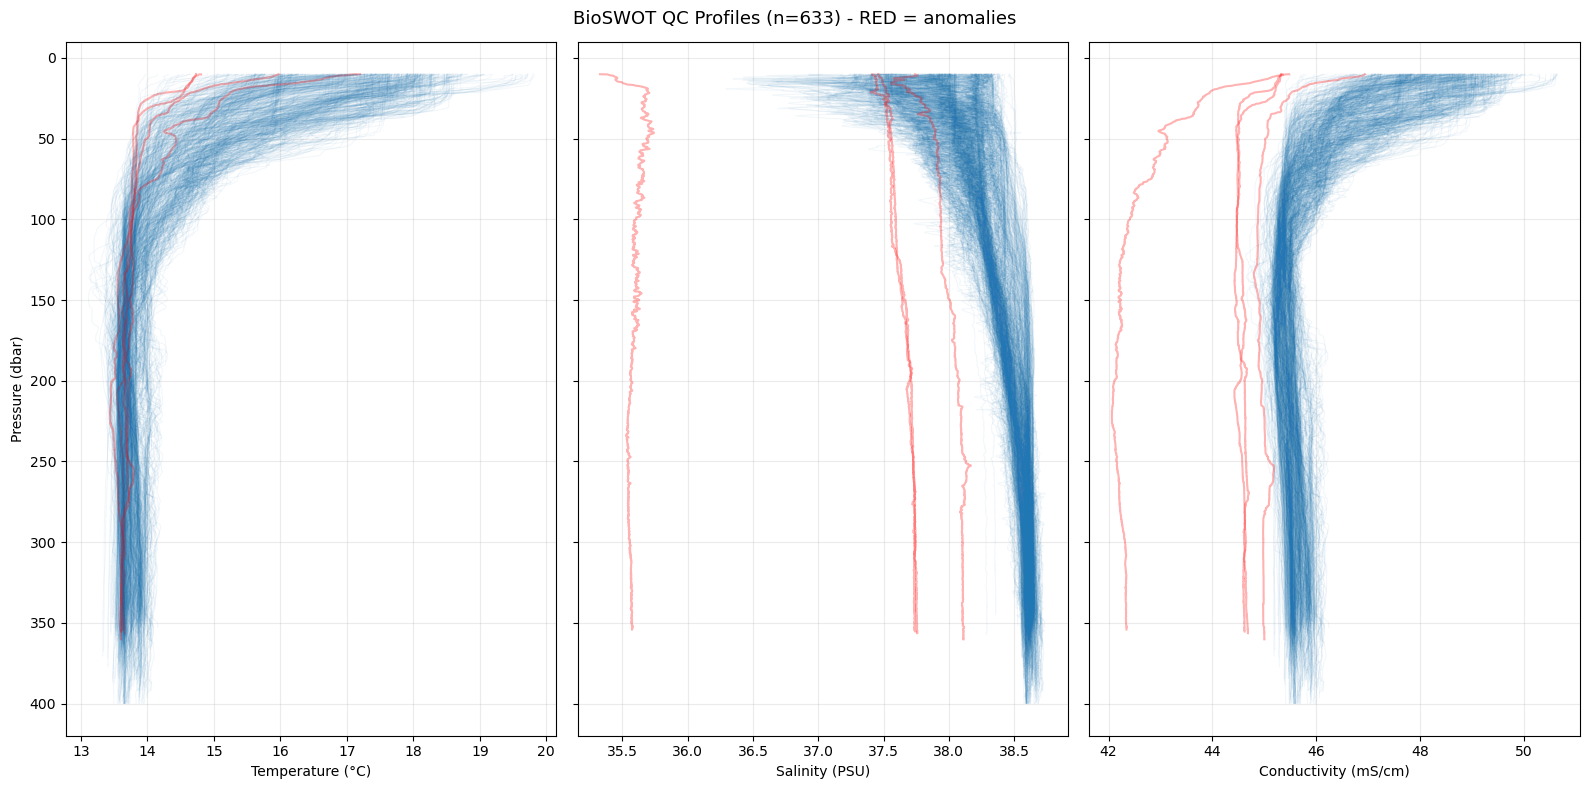


   🚨 Anomalous profiles (|Z| > 2 sigma):
      PL2_pl2_0029_step1_qc.nc: Z=-5.28, S_mean=37.6721 PSU
      PL2_pl2_0033_step1_qc.nc: Z=-5.32, S_mean=37.6667 PSU
      PL7_mvp_2023-04-29_001820_step1_qc.nc: Z=-19.78, S_mean=35.5849 PSU
      PL7_mvp_2023-04-29_034629_step1_qc.nc: Z=-2.84, S_mean=38.0232 PSU

   Removing 4 anomalous profile(s)...
   ✅ Deleted 4 anomalous files
   ✅ Remaining profiles: 629

STEP 1 COMPLETE: QC Processing + Anomaly Removal


In [4]:
import matplotlib.pyplot as plt
# =========================
# STEP 1.2: PROFILE ANOMALY DETECTION & REMOVAL
# =========================
# Detects anomalous profiles based on Z-score of mean salinity
# Visualizes all profiles (anomalies highlighted in RED)
# Removes the detected bad profiles from the processed output

print("\n" + "="*80)
print("STEP 1.2: DETECTING & REMOVING ANOMALOUS PROFILES")
print("="*80)

for leg, cfg in LEG_CFG.items():
    raw_dir = cfg["raw_dir"]
    qc_dir = raw_dir.parent / OUT_SUBDIR
    
    if not qc_dir.exists():
        print(f"⚠️ QC directory not found: {qc_dir}")
        continue
    
    qc_files = sorted(list(qc_dir.glob("*_step1_qc.nc")))
    print(f"\n[{leg.upper()}] Analyzing {len(qc_files)} processed profiles...")
    
    # --- 1. CALCULATE Z-SCORES FOR SALINITY ---
    profiles_stats = []
    
    for f in qc_files:
        try:
            ds = xr.open_dataset(f)
            s = ds['s_raw'].values.astype(float)
            valid = np.isfinite(s)
            if valid.sum() > 10:
                profiles_stats.append({
                    'file': f.name,
                    's_mean': np.nanmean(s[valid])
                })
            ds.close()
        except:
            pass
    
    df_stats = pd.DataFrame(profiles_stats)
    s_mean_ens = df_stats['s_mean'].mean()
    s_std_ens = df_stats['s_mean'].std()
    df_stats['z_score'] = (df_stats['s_mean'] - s_mean_ens) / s_std_ens
    df_stats['is_anomaly'] = np.abs(df_stats['z_score']) > 2.0
    
    anomaly_count = df_stats['is_anomaly'].sum()
    print(f"   Ensemble mean S: {s_mean_ens:.4f} PSU")
    print(f"   Ensemble std S: {s_std_ens:.4f} PSU")
    print(f"   Anomalies detected: {anomaly_count} / {len(df_stats)}")
    
    # --- 2. VISUALIZE PROFILES WITH ANOMALIES HIGHLIGHTED ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)
    fig.suptitle(f"BioSWOT QC Profiles (n={len(qc_files)}) - RED = anomalies", fontsize=13)
    
    for f in qc_files:
        try:
            ds = xr.open_dataset(f)
            
            p = np.asarray(ds['pressure'].values, dtype=float)
            if p.ndim != 1 or p.size == 0:
                ds.close()
                continue
            
            # Check if this profile is anomalous
            s_mean_val = df_stats[df_stats['file'] == f.name]['s_mean'].values
            is_anom = df_stats[df_stats['file'] == f.name]['is_anomaly'].values[0] if len(s_mean_val) > 0 else False
            
            color = 'red' if is_anom else 'tab:blue'
            alpha = 0.3 if is_anom else 0.06
            lw = 1.5 if is_anom else 0.7
            
            # Temperature
            t = np.asarray(ds['t1'].values, dtype=float)
            ok = np.isfinite(t) & np.isfinite(p)
            if np.any(ok):
                axes[0].plot(t[ok], p[ok], color=color, alpha=alpha, lw=lw)
            
            # Salinity
            s = np.asarray(ds['s_raw'].values, dtype=float)
            ok = np.isfinite(s) & np.isfinite(p)
            if np.any(ok):
                axes[1].plot(s[ok], p[ok], color=color, alpha=alpha, lw=lw)
            
            # Conductivity
            c = np.asarray(ds['c1'].values, dtype=float)
            ok = np.isfinite(c) & np.isfinite(p)
            if np.any(ok):
                axes[2].plot(c[ok], p[ok], color=color, alpha=alpha, lw=lw)
            
            ds.close()
        except Exception as e:
            print(f"   ⚠️ Error plotting {f.name}: {e}")
            continue
    
    axes[0].set_xlabel('Temperature (°C)')
    axes[1].set_xlabel('Salinity (PSU)')
    axes[2].set_xlabel('Conductivity (mS/cm)')
    axes[0].set_ylabel('Pressure (dbar)')
    axes[0].invert_yaxis()
    
    for ax in axes:
        ax.grid(True, alpha=0.25)
    
    plt.tight_layout()
    plt.show()
    
    # --- 3. PRINT ANOMALOUS PROFILES ---
    if anomaly_count > 0:
        print(f"\n   🚨 Anomalous profiles (|Z| > 2 sigma):")
        for idx, row in df_stats[df_stats['is_anomaly']].iterrows():
            print(f"      {row['file']}: Z={row['z_score']:+.2f}, S_mean={row['s_mean']:.4f} PSU")
    
    # --- 4. DELETE ANOMALOUS PROFILE FILES ---
    if anomaly_count > 0:
        print(f"\n   Removing {anomaly_count} anomalous profile(s)...")
        removed = 0
        for idx, row in df_stats[df_stats['is_anomaly']].iterrows():
            file_path = qc_dir / row['file']
            try:
                file_path.unlink()
                removed += 1
            except Exception as e:
                print(f"      ❌ Could not delete {row['file']}: {e}")
        
        print(f"   ✅ Deleted {removed} anomalous files")
        print(f"   ✅ Remaining profiles: {len(df_stats) - removed}")
    else:
        print(f"   ✅ No anomalies detected. All {len(df_stats)} profiles retained.")

print("\n" + "="*80)
print("STEP 1 COMPLETE: QC Processing + Anomaly Removal")
print("="*80)